In [2]:
import os
import tensorflow as tf
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import ReduceLROnPlateau, ModelCheckpoint, EarlyStopping
from tensorflow.keras.regularizers import l2
import zipfile
import matplotlib.pyplot as plt

In [3]:
# ==========================================
# 1. DEFINIZIONE DEI PERCORSI
# ==========================================
TRAIN_DIR = 'rps.zip'           # Cartella estratta da rps.zip
TEST_DIR = 'rps-test-set.zip'   # Cartella estratta da rps-test-set.zip

# 1. Funzione per estrarre i file zip se la cartella non esiste
def gestisci_dataset(zip_name, folder_name):
    if not os.path.exists(folder_name):
        if os.path.exists(zip_name):
            print(f"Estrazione di '{zip_name}' in corso...")
            with zipfile.ZipFile(zip_name, 'r') as zip_ref:
                zip_ref.extractall('.')
            print(f"Estrazione di '{zip_name}' completata!")
        else:
            print(f"ERRORE: Non trovo né la cartella '{folder_name}' né il file '{zip_name}' nella cartella corrente!")
            print(f"Directory attuale: {os.getcwd()}")
            return None

    # Gestione cartelle annidate (es. rps/rps)
    nested_path = os.path.join(folder_name, folder_name)
    if os.path.exists(nested_path):
        return nested_path
    return folder_name

# 2. Assegnazione percorsi validati
TRAIN_DIR = gestisci_dataset('rps.zip', 'rps')
TEST_DIR = gestisci_dataset('rps-test-set.zip', 'rps-test-set')

print(f"\n📁 Percorso Training impostato: '{TRAIN_DIR}'")
print(f"📁 Percorso Test impostato: '{TEST_DIR}'")

Estrazione di 'rps.zip' in corso...
Estrazione di 'rps.zip' completata!
Estrazione di 'rps-test-set.zip' in corso...
Estrazione di 'rps-test-set.zip' completata!

📁 Percorso Training impostato: 'rps'
📁 Percorso Test impostato: 'rps-test-set'


In [4]:
# ==========================================
# 2. IMPOSTAZIONE DI IMAGEDATAGENERATOR E DATASET
# ==========================================
IMG_SIZE = (150,150)
BATCH_SIZE = 32
SEED = 42

# Riproducibilità
tf.keras.utils.set_random_seed(SEED)

datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',      
    validation_split=0.15
)

# Generatore per il TRAINING
train_generator = datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    seed=SEED,
    shuffle=True
)

# Generatore per la VALIDAZIONE (stessa istanza 'datagen')
val_generator = datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    seed=SEED,
    shuffle=False
)

# Generatore per il TEST (solo rescaling)
test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 2142 images belonging to 3 classes.
Found 378 images belonging to 3 classes.
Found 372 images belonging to 3 classes.


In [5]:
# ==========================================
# 3. IMPOSTAZIONE DI PESI PER IL TRAIN
# ==========================================

# Forziamo un extra-peso manuale alla classe 'paper' (indice 0) per penalizzare gli errori 
# Nei test di addestramento rock veniva usato come 'salvagente'
class_weights = {
    0: 1.4,  # paper: peso maggiorato
    1: 0.8,  # rock: peso ridotto per smettere di usarlo come "salvagente"
    2: 1.0   # scissors: peso standard
}
print(f"Pesi assegnati alle classi: {class_weights}")


Pesi assegnati alle classi: {0: 1.4, 1: 0.8, 2: 1.0}


In [6]:
# ==========================================
# 4. ARCHITETTURA CNN CUSTOM 
# ==========================================
model = models.Sequential([
    # Blocco 1
    layers.Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(150, 150, 3)),
    layers.MaxPooling2D((2, 2)),

    # Blocco 2
    layers.Conv2D(64, (3, 3), padding='same', activation='relu', kernel_regularizer=l2(0.001)),
    layers.MaxPooling2D((2, 2)),

    # Blocco 3
    layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Blocco 4
    layers.Conv2D(256, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Classification
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(3, activation='softmax')
], name="Custom_RPS_CNN_IDG")

c:\Users\GIOVANNI\Documents\GitHub\DEEP LEARNING 2\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
# ==========================================
# 5. COMPILAZIONE CON LABEL SMOOTHING
# ==========================================
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

In [8]:
# ==========================================
# 6. CALLBACKS E FIT
# ==========================================
callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1),
    ModelCheckpoint('best_rps_model.keras', monitor='val_accuracy', save_best_only=True, verbose=1)
]

history = model.fit(
    train_generator,
    epochs=20,
    validation_data=val_generator,
    callbacks=callbacks
)

Epoch 1/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step - accuracy: 0.5019 - loss: 1.0287
Epoch 1: val_accuracy improved from None to 0.69841, saving model to best_rps_model.keras

Epoch 1: finished saving model to best_rps_model.keras
67/67 ━━━━━━━━━━━━━━━━━━━━ 19s 263ms/step - accuracy: 0.5019 - loss: 1.0287 - val_accuracy: 0.6984 - val_loss: 0.9127 - learning_rate: 3.0000e-04
Epoch 2/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step - accuracy: 0.8007 - loss: 0.6888
Epoch 2: val_accuracy did not improve from 0.69841
67/67 ━━━━━━━━━━━━━━━━━━━━ 16s 245ms/step - accuracy: 0.8007 - loss: 0.6888 - val_accuracy: 0.6772 - val_loss: 0.9217 - learning_rate: 3.0000e-04
Epoch 3/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step - accuracy: 0.9127 - loss: 0.5244
Epoch 3: val_accuracy improved from 0.69841 to 0.81746, saving model to best_rps_model.keras

Epoch 3: finished saving model to best_rps_model.keras
67/67 ━━━━━━━━━━━━━━━━━━━━ 17s 254ms/step - accuracy: 0.9127 - loss: 0.5244 - val_accuracy: 0.8175 - val

In [9]:
# ==========================================
# 7. VALUTAZIONE SUL TEST SET INDIPENDENTE
# ==========================================

test_loss, test_acc = model.evaluate(test_generator)
print(f"\n--- Valutazione finale sul Test Set ---")
print(f"Test Accuracy: {test_acc * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - accuracy: 0.9785 - loss: 0.3907

--- Valutazione finale sul Test Set ---
Test Accuracy: 97.85%
Test Loss: 0.3907


In [10]:
# ==========================================
# 8. CONFUSION MATRIX
# ==========================================

# Reset del generatore per assicurare l'ordine corretto
test_generator.reset()

# Predizioni sul Test Set
predictions = model.predict(test_generator)
y_pred = np.argmax(predictions, axis=1)
y_true = test_generator.classes

# Etichette delle classi
class_labels = list(test_generator.class_indices.keys())

print("--- CLASSIFICATION REPORT ---")
print(classification_report(y_true, y_pred, target_names=class_labels))

print("\n--- CONFUSION MATRIX ---")
print(confusion_matrix(y_true, y_pred))

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step
--- CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

       paper       1.00      0.94      0.97       124
        rock       0.94      1.00      0.97       124
    scissors       1.00      1.00      1.00       124

    accuracy                           0.98       372
   macro avg       0.98      0.98      0.98       372
weighted avg       0.98      0.98      0.98       372


--- CONFUSION MATRIX ---
[[116   8   0]
 [  0 124   0]
 [  0   0 124]]


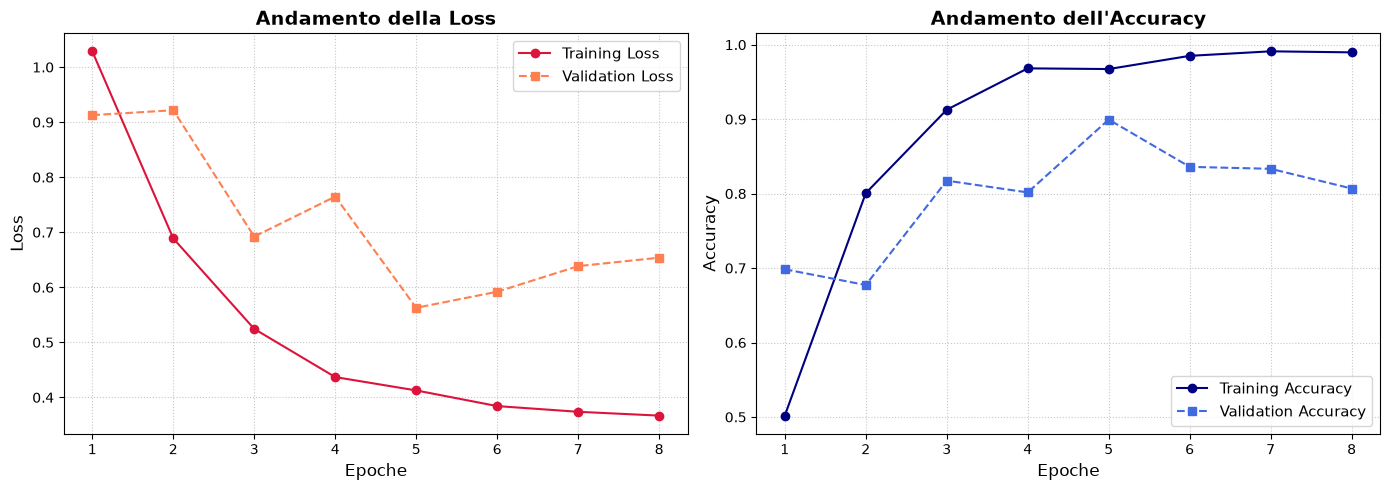

✅ Grafico salvato con successo in: 'training_performance.png'


In [11]:
# ==========================================
# 9. GRAFICI DI LOSS E ACCURACY
# ==========================================

# Estrazione dei dati dallo storico (history)
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(1, len(acc) + 1)

# Creazione della figura con 2 subplots affiancati
plt.figure(figsize=(14, 5))

# --- GRAFICO 1: LOSS ---
plt.subplot(1, 2, 1)
plt.plot(epochs_range, loss, label='Training Loss', color='crimson', linestyle='-', marker='o')
plt.plot(epochs_range, val_loss, label='Validation Loss', color='coral', linestyle='--', marker='s')
plt.title('Andamento della Loss', fontsize=14, fontweight='bold')
plt.xlabel('Epoche', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(loc='upper right', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.7)

# --- GRAFICO 2: ACCURACY ---
plt.subplot(1, 2, 2)
plt.plot(epochs_range, acc, label='Training Accuracy', color='navy', linestyle='-', marker='o')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='royalblue', linestyle='--', marker='s')
plt.title('Andamento dell\'Accuracy', fontsize=14, fontweight='bold')
plt.xlabel('Epoche', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.7)

# Ottimizzazione dello spazio, visualizzazione e salvataggio su disco
plt.tight_layout()

chart_filename = 'training_performance.png'
plt.savefig(chart_filename, dpi=300)
plt.show()
print(f"✅ Grafico salvato con successo in: '{chart_filename}'")

plt.show()



In [12]:
# ==========================================
#  SALVATAGGIO DEL MODELLO
# ==========================================

model_filename = 'rps_custom_model.keras'
model.save(model_filename)
print(f"✅ Modello salvato con successo in: '{model_filename}'")

✅ Modello salvato con successo in: 'rps_custom_model.keras'
